Partie 1 – Distribution d'une variable avec histplot() 
1) Afficher la distribution des températures 
2) Autour de quelle valeur les températures sont concentrées ? 
3) La distribution semble-t-elle symétrique ? 
4) Existe-t-il des valeurs extrêmes ? 
5) Modifier le nombre de classes 
6) Afficher la distribution des températures par bâtiment 

In [47]:
%pip install seaborn pandas numpy matplotlib

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


In [48]:
df =pd.read_csv("../data/mesures_capteurs.csv")
#print(df)
print(df.head())

  id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0     M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1     M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2     M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3     M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4     M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   

   pression  consommation etat  
0   1008.95        287.28   OK  
1    993.39        116.20   OK  
2   1010.32        288.50   OK  
3   1019.62        136.65   OK  
4   1016.58        182.62   OK  


1) Afficher la distribution des températures 

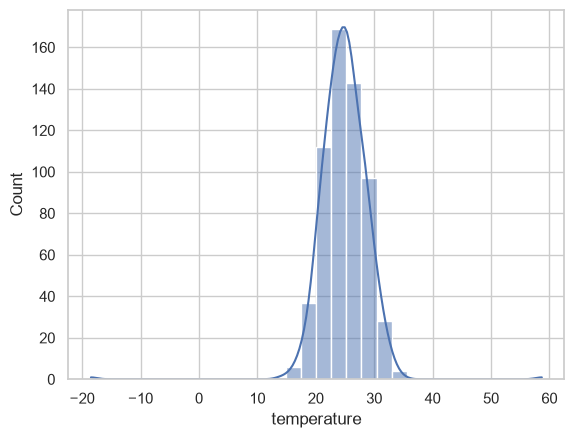

In [ ]:
#plt.figure(figsize=(7, 4))
sns.histplot(data=df,x="temperature",bins=30,kde=True)
plt.savefig(
    "../exports/histplot_temperature.png",
    dpi=300,
    bbox_inches="tight"
)
#plt.tight_layout
#plt.show

2) Autour de quelle valeur les températures sont concentrées ?

A travers le graphique , on peut visualiser une forte tendance autour de 20-30 principalement à une valeur approximative de 25 . 
On peut alors dire que les valeurs sont concentrées autour de 25.

3) La distribution semble-t-elle symétrique ? 

Autour de 25 on peut entrevoir une simulitude de part et d'autre , dans la construction des barres de cet histogramme . Alors , oui , la distribution semble symétriqye

4) Existe-t-il des valeurs extrêmes ? 

Toujours dans l'aspect visuel de ce graphique , on peut voir vers -20 et vers 60 une représentation de ces valeurs la qui sont les valeurs extrêmes du dataset.

5) Modifier le nombre de classes 

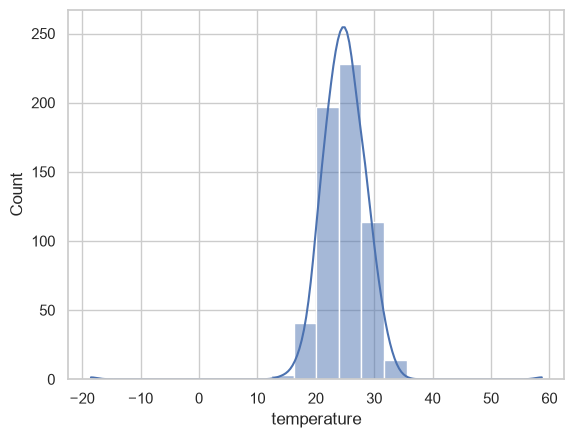

In [ ]:
#plt.figure(figsize=(7, 4))
sns.histplot(data=df,x="temperature",bins=20,kde=True)
plt.savefig(
    "../exports/histplot_temperature_20bins.png",
    dpi=300,
    bbox_inches="tight"
)
#plt.show

6) Afficher la distribution des températures par bâtiment 

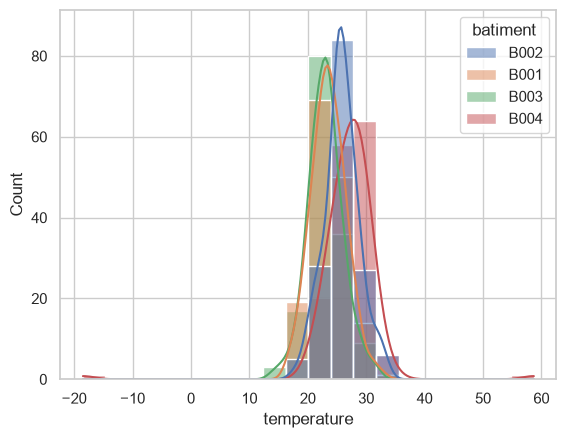

In [ ]:
#plt.figure(figsize=(7, 4))
sns.histplot(data=df,x="temperature",bins=20,kde=True,hue="batiment")
plt.savefig(
    "../exports/histplot_temperature_batiment.png",
    dpi=300,
    bbox_inches="tight"
)
#plt.show

Partie 2 – Distribution d'une variable avec kdeplot() 
1) Afficher la distribution des températures 
2) Afficher la distribution des températures par bâtiment 

1) Afficher la distribution des températures 

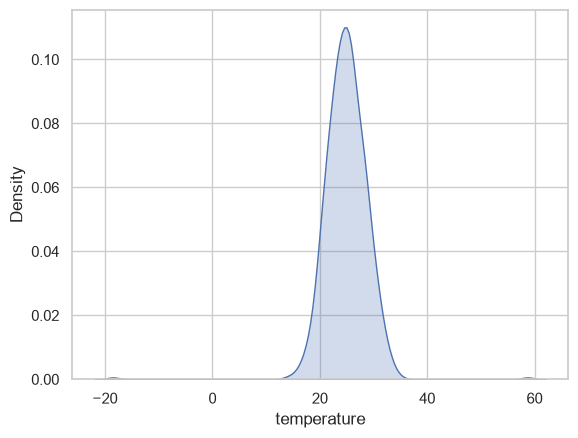

In [ ]:
sns.kdeplot(data=df,x="temperature",fill=True)
plt.savefig(
    "../exports/kde_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

2) Afficher la distribution des températures par bâtiment 

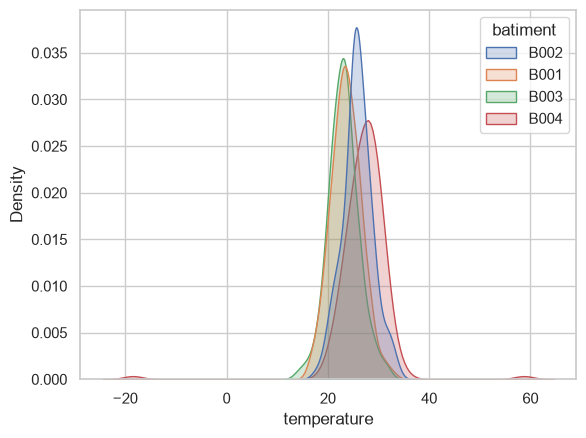

In [94]:
sns.kdeplot(data=df,x="temperature",fill=True ,hue="batiment")
plt.savefig(
    "../exports/kde_temperature_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

Partie 3 – Distribution d'une variable avec boxplot() 
1) Afficher la distribution des températures 
2) Afficher la distribution des températures par bâtiment 
3) Pour chaque bâtiment, 

a)quelle est la médiane ?  

b) quelle est la dispersion ?  

c) les valeurs extrêmes 

4) quels bâtiments ont les valeurs les plus extrêmes ? 

1) Afficher la distribution des températures 

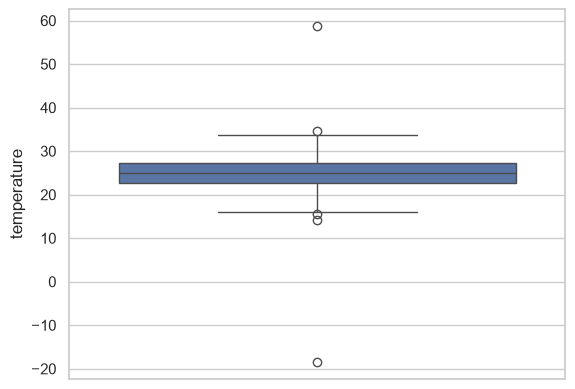

In [ ]:
sns.boxplot(data=df,y="temperature")
plt.savefig(
    "../exports/boxplot_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

2) Afficher la distribution des températures par bâtiment

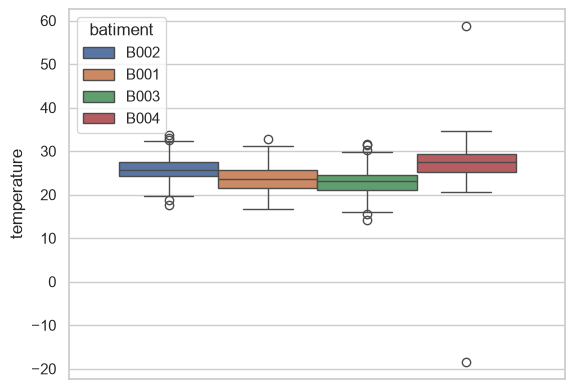

In [95]:
boite2=sns.boxplot(data=df,y="temperature",hue="batiment")
plt.savefig(
    "../exports/boxplot_temperature_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

3) Pour chaque bâtiment, 

a) quelle est la médiane ?  

b) quelle est la dispersion ?  

c) les valeurs extrêmes 

In [63]:
def compter_outliers(groupe):
    q1 = groupe.quantile(0.25)
    q3 = groupe.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    return ((groupe < borne_basse) | (groupe > borne_haute)).sum()

nb_outliers = df.groupby("batiment")["temperature"].apply(compter_outliers)
print(nb_outliers)

batiment
B001    1
B002    5
B003    5
B004    2
Name: temperature, dtype: int64


In [64]:
resume = df.groupby("batiment")["temperature"].agg(
    mediane="median",
    ecart_type="std",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    minimum="min",
    maximum="max"
).round(2)
resume["IQR"] = (resume["Q3"] - resume["Q1"]).round(2)
resume["nb_outliers"] = df.groupby("batiment")["temperature"].apply(compter_outliers)
print(resume)

          mediane  ecart_type     Q1     Q3  minimum  maximum   IQR  \
batiment                                                              
B001        23.54        2.96  21.61  25.67    16.77    32.72  4.06   
B002        25.67        2.95  24.27  27.53    17.67    33.60  3.26   
B003        23.04        2.98  21.08  24.60    14.11    31.74  3.52   
B004        27.53        5.37  25.17  29.28   -18.50    58.70  4.11   

          nb_outliers  
batiment               
B001                1  
B002                5  
B003                5  
B004                2  


Médiane : B004 a la médiane la plus haute (27,67 °C) ; B001 et B003 sont proches et plus basses (~23-23,6 °C) ; B002 se situe entre les deux

Dispersion : B001, B002, B003 ont une dispersion comparable (écart-type ~3) ; B004 se distingue nettement avec un écart-type quasi double, signe de mesures beaucoup plus instables

Valeurs extrêmes : concentrées sur B004, qui porte les deux valeurs aberrantes (-18,5 et 58,7 °C) — très probablement un capteur défectueux sur ce bâtiment, à investiguer en priorité avant toute utilisation pour du Machine Learning  

4) quels bâtiments ont les valeurs les plus extrêmes ? 

Bien que les bâtiments B002 et B003 concentrent le plus grand nombre de valeurs extrêmes, c'est le bâtiment B004 qui enregistre les deux valeurs les plus absolues du jeu de données : le minimum (-18,50) et le maximum (58,70).

Partie 4 – Distribution d'une variable avec violinplot() 
1) Afficher la distribution des températures 
2) Afficher la distribution des températures par bâtiment 
3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box 
plot ? 

1) Afficher la distribution des températures

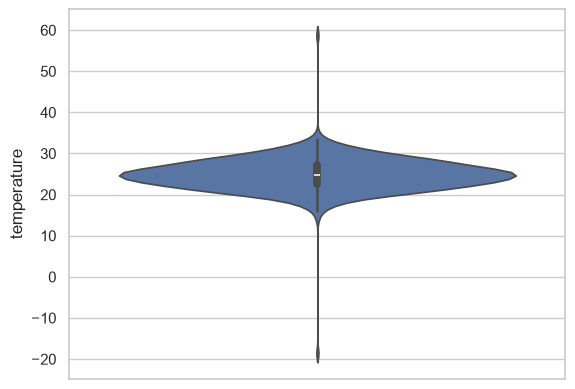

In [96]:
sns.violinplot(data=df,y="temperature")
plt.savefig(
    "../exports/violinplot_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

2) Afficher la distribution des températures par bâtiment 

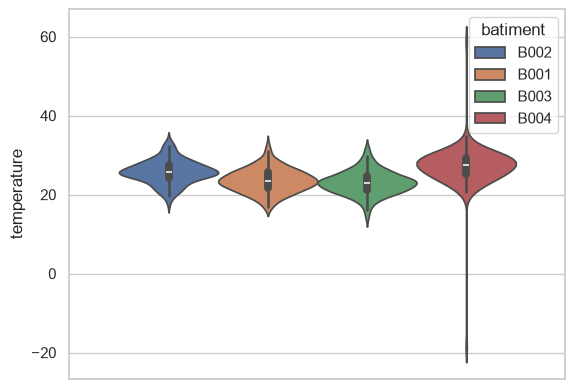

In [97]:
violon2=sns.violinplot(data=df,y="temperature",hue="batiment")
plt.savefig(
    "../exports/violinplot_temperature_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box 
plot ?

Le boxplot montre principalement :

médiane ;
quartiles ;
IQR ;
valeurs extrêmes.

Le violin plot montre également la forme de la distribution ainsi que les points de densités

Partie 5 – Comptage des catégories avec countplot() 
1) Afficher le nombre de mesures par état  
2) Afficher le nombre de mesures par bâtiment 
3) Afficher les états des capteurs par bâtiment pour identifier  

a) le bâtiment ayant le plus de mesures en état OK ; 

b) celui ayant le plus de mesures en ALERTE ; 

c) celui ayant le plus de mesures en ERREUR. 


1) Afficher le nombre de mesures par état  

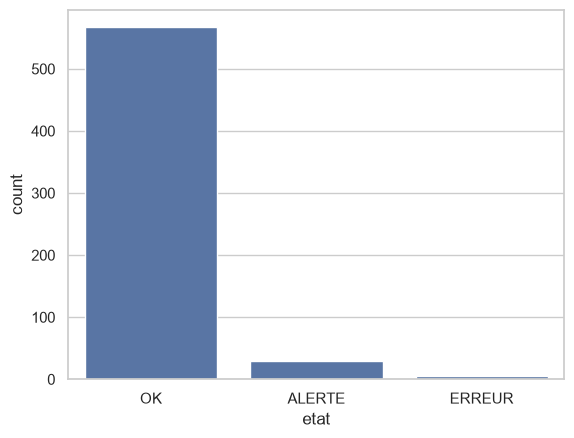

In [98]:
sns.countplot(data=df ,x="etat")
plt.savefig(
    "../exports/countplot_etat.png",
    dpi=300,
    bbox_inches="tight"
)

2) Afficher le nombre de mesures par bâtiment 

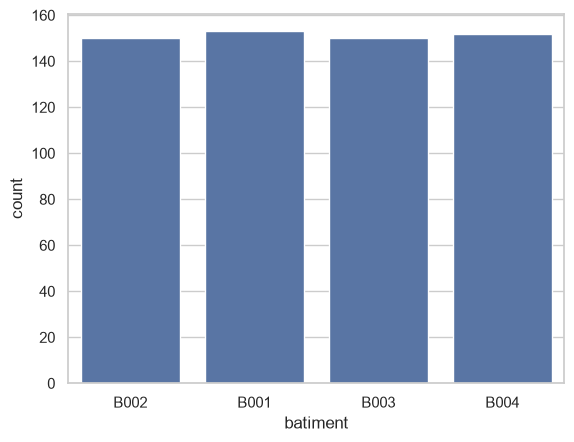

In [99]:
sns.countplot(data=df,x="batiment")
plt.savefig(
    "../exports/countplot_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

3) Afficher les états des capteurs par bâtiment pour identifier  

a) le bâtiment ayant le plus de mesures en état OK ; 

b) celui ayant le plus de mesures en ALERTE ; 

c) celui ayant le plus de mesures en ERREUR.

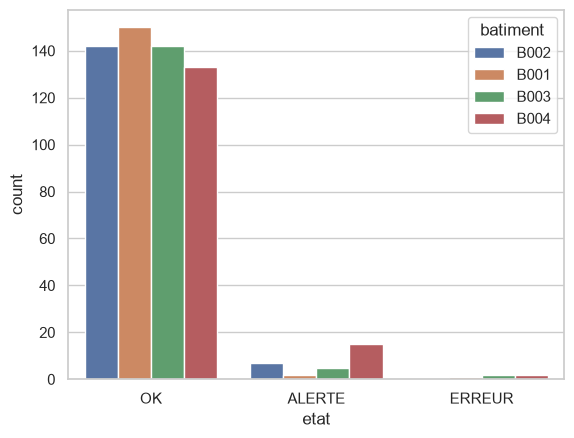

In [100]:
sns.countplot(data=df,x="etat", hue="batiment")
plt.savefig(
    "../exports/countplot_etat_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

a) le bâtiment ayant le plus de mesures en état OK 

 B001

b) celui ayant le plus de mesures en ALERTE 

 B004

c) celui ayant le plus de mesures en ERREUR

 B003-B004

Partie 6 – Relation entre deux variables avec scatterplot() 
1) Etudier graphiquement la relation entre température et consommation 
2) Etudier graphiquement la relation entre température et consommation par bâtiment 
3) Modifier la taille des points

1) Etudier graphiquement la relation entre température et consommation 


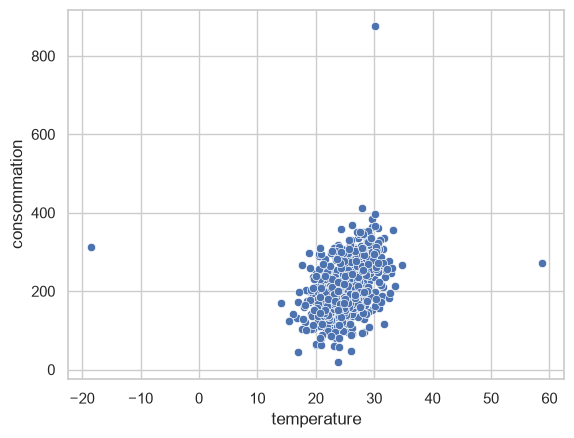

In [101]:
sns.scatterplot(data=df,x="temperature",y="consommation")
plt.savefig(
    "../exports/scatter_temperature_consommation.png",
    dpi=300,
    bbox_inches="tight"
)

2) Etudier graphiquement la relation entre température et consommation par bâtiment 


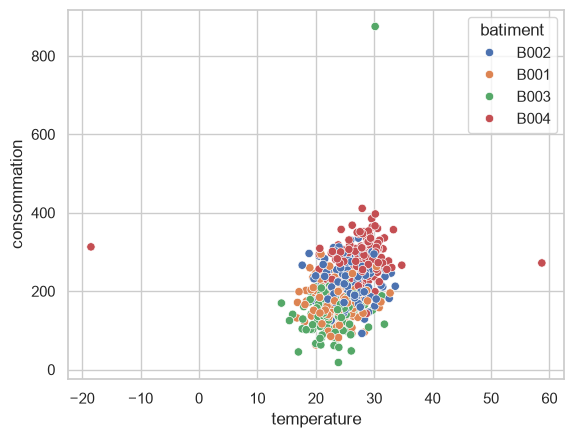

In [102]:
sns.scatterplot(data=df,x="temperature",y="consommation",hue="batiment")
plt.savefig(
    "../exports/scatter_temperature_consommation_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

3) Modifier la taille des points 

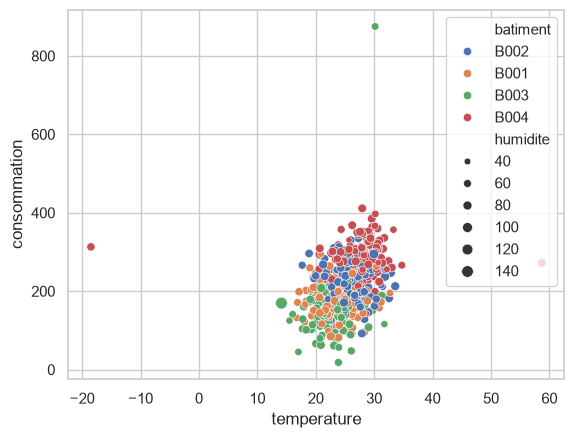

In [103]:
sns.scatterplot(data=df,x="temperature",y="consommation",hue="batiment",size="humidite")
plt.savefig(
    "../exports/scatter_temperature_consommation_humidite.png",
    dpi=300,
    bbox_inches="tight"
)

Partie 7 – Régression avec regplot() 

Etudier graphiquement une tendance entre température et consommation 

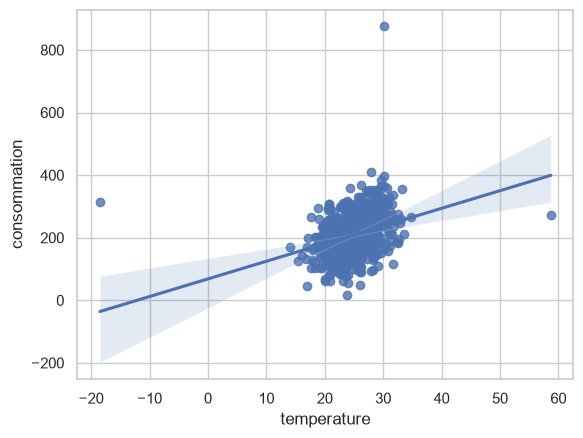

In [104]:
Regplot=sns.regplot(data=df,x="temperature",y="consommation")
plt.savefig(
    "../exports/regplot_temperature_consommation.png",
    dpi=300,
    bbox_inches="tight"
)

La droite nous permet de voir plus facilement la tendance générale.La tendance générale suggère une relation positive entre température et consommation.

Partie 8 – Régression avec lmplot() 

Etudier graphiquement une tendance entre température et consommation par bâtiment 


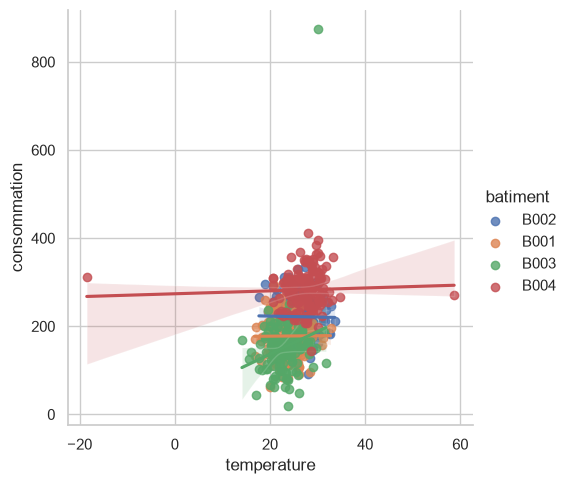

In [106]:
Implot=sns.lmplot(data=df,x="temperature",y="consommation",hue="batiment")
Implot.savefig(
    "../exports/lmplot_temperature_consommation_batiment.png",
    dpi=300,
    bbox_inches="tight"
)

La relation entre température et consommation varie selon les bâtiments. 
Le bâtiment B003 présente une tendance de relation plus faible.

Partie 9 – Corrélations 
1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et 
consommation.  
2) Afficher la matrice de corrélation obtenue avec Pandas 
3) Afficher le heatmap de la corrélation pour identifier : 
a) les corrélations positives ;  
b) les corrélations négatives ;  
c) les corrélations proches de zéro ;  
d) les variables qui semblent fortement liées. 

1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et 
consommation.  

In [ ]:
%pip install pandas
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [65]:
matrice_corr=df[["temperature","consommation","humidite","pression"]].corr()

2) Afficher la matrice de corrélation obtenue avec Pandas 

In [ ]:
print(matrice_corr)

              temperature  consommation  humidite  pression
temperature      1.000000      0.317048 -0.006126  0.061283
consommation     0.317048      1.000000 -0.046061  0.056051
humidite        -0.006126     -0.046061  1.000000  0.045242
pression         0.061283      0.056051  0.045242  1.000000


3) Afficher le heatmap de la corrélation pour identifier : 
a) les corrélations positives ;  
b) les corrélations négatives ;  
c) les corrélations proches de zéro ;  
d) les variables qui semblent fortement liées. 

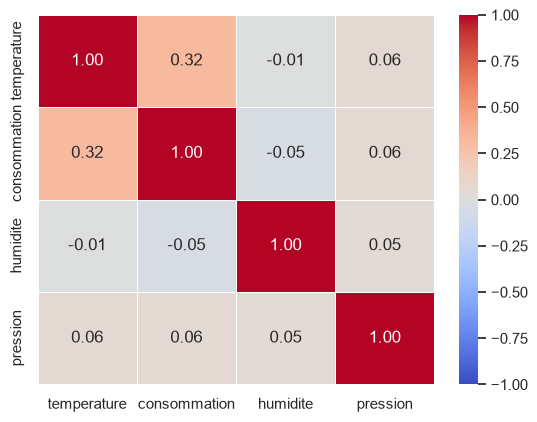

In [107]:
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.savefig(
    "../exports/heatmap_correlation.png",
    dpi=300,
    bbox_inches="tight"
)


a) les corrélations positives                : temperature-consommation

b) les corrélations négatives                :
consommation-humidite  ; temperature-humidite 

c) les corrélations proches de zéro          :
consommation-pression ; temperature-pression ; humidite-temperature ; humidite-pression

d) les variables qui semblent fortement liées:
Aucune. La corrélation la plus élevée du dataset est temperature-consommation (0,317), 
mais elle reste modérée (bien en dessous du seuil de ~0,5-0,7 généralement associé 
à une corrélation "forte"). Toutes les autres paires sont proches de zéro.

Partie 10 – Analyse multivariée avec pairplot() 

En considérant la température, l’humidité, la pression et la consommation, réaliser un graphique qui 
affiche simultanément les distributions individuelles et les scatter plots entre variables. 


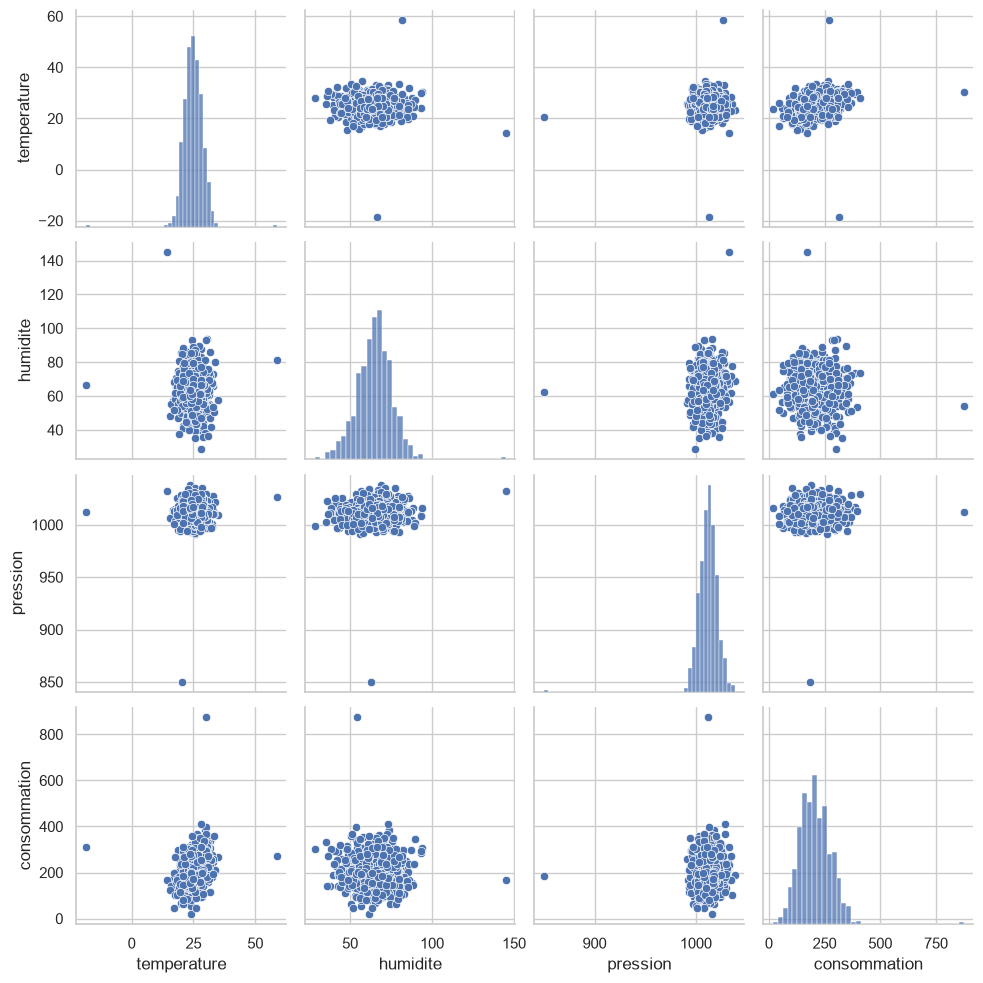

In [108]:
sns.pairplot(df[["temperature","humidite","pression","consommation"]])
pairplot.savefig(
    "../exports/pairplot_variables.png",
    dpi=300,
    bbox_inches="tight"
)

Partie 11 : Sauvegarde des graphiques 
Sauvegarder les graphiques dans le sous-dossier exports 

La sauvegarde est assurée à chaque partie , après création de graphique avec un code similaire au suivant:

"plt.savefig(
    "../exports/histplot_temperature.png",
    dpi=300,
    bbox_inches="tight"
)"

Partie 12 : Bonus 

Proposer et réaliser toute fonctionnalité pertinente et utile qu’on pourrait rajouter à l’atelier.

datetime64[us]


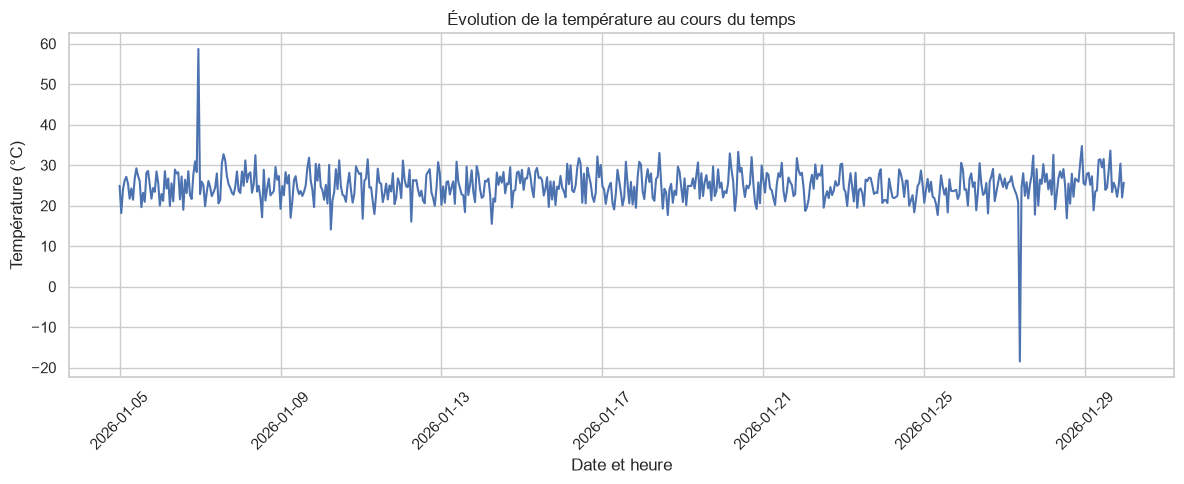

In [109]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
print(df["date_heure"].dtype)
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df,
    x="date_heure",
    y="temperature"
)

plt.title("Évolution de la température au cours du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../exports/evolution_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


« Comment la température évolue-t-elle dans le temps ? »
est la question principale que ce code essai de résoudre. 
Avec cette donnée , on peut essayer d'entrevoir des éléments comme la consommation par heure et l'humidité pourquoi pas .